# Buy-Side Quant Finance: A Pedagogical Tour

This notebook is intentionally **not** a polished deliverable. It's a working document to build intuition for the core models every quant equity shop uses — CAPM, factor models, covariance estimation, and how they connect.

The progression goes:
1. **CAPM** — why one factor explains most of stock variance, and what's left over
2. **Multi-factor models** — Fama-French and the general linear factor model
3. **Covariance matrix estimation** — the dirty secret of portfolio construction
4. **Mean-variance optimisation** — Markowitz, why it breaks, and fixes
5. **Factor-based portfolio construction** — how quants actually build portfolios

We use our 15-stock universe (S&P 500 names, daily data 2018–2026) throughout. The goal is always: see the math, see the code, see what it tells us on real data.

---
**Notation reminder** (consistent with `theory.md`):
- $R_{i,t}$: simple return of stock $i$ at time $t$
- $r_{i,t} = \log(1+R_{i,t})$: log return (we use log returns for estimation)
- $\mathbf{r}_t \in \mathbb{R}^N$: cross-sectional vector of log returns at time $t$
- $\mathbf{w}$: portfolio weight vector

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

# ── Load data ───────────────────────────────────────────────────────────────
log_returns = pd.read_parquet('../data/processed/log_returns.parquet')

print(f"Universe  : {list(log_returns.columns)}")
print(f"Date range: {log_returns.index[0].date()} → {log_returns.index[-1].date()}")
print(f"Obs / stock: {len(log_returns):,}")

Universe  : ['AAPL', 'AMZN', 'CVX', 'GOOGL', 'GS', 'JPM', 'KO', 'LLY', 'META', 'MSFT', 'NVDA', 'PEP', 'PG', 'UNH', 'XOM']
Date range: 2018-01-03 → 2026-03-31
Obs / stock: 2,071


---
## Part 1 — CAPM

### The idea
*If I hold a risky asset, how much extra return should I demand as compensation?*

This is a classic question. Compensation here means how much we get paid for bearing a risk that someone else doesn't want. The entire key point of the discussion is about figuring it out which risks get compensated and how much. The Capital Asset Pricing Model (Sharpe 1964, Lintner 1965) is the foundation, and gives a precise, radical, clean answer. Its central claim: 

**In equilibrium, the only risk that is compensated is systematic (market) risk. Only one risk gets compensated: the risk of the market going down. Everything else can be eliminated for free.**

Any idiosyncratic risk can be diversified away, so rational investors don't demand extra return for bearing it.

The model equation (in expected-return form):

$$\mathbb{E}[R_i] - R_f = \beta_i \bigl(\mathbb{E}[R_m] - R_f\bigr)$$

- $R_i$: return of stock $i$ 
- $R_f$: risk-free rate
- $R_m$: market return
- $\mathbb{E}[R_m] - R_f$: **equity risk premium** (ERP) — extra return for owning the market
- $\beta_i$: **beta** — sensitivity of stock $i$ to market moves

In time-series regression form (the testable version):

$$r_{i,t} - r_{f,t} = \alpha_i + \beta_i \underbrace{(r_{m,t} - r_{f,t})}_{\text{market excess return}} + \varepsilon_{i,t}$$

CAPM says $\alpha_i = 0$ for all stocks (no free lunch). **Jensen's alpha** is the empirical $\hat\alpha_i$ — evidence of mispricing or a missing factor.

### What beta actually measures

$$\beta_i = \frac{\mathrm{Cov}(r_i, r_m)}{\mathrm{Var}(r_m)}$$

This is just an OLS slope — regress excess stock return on excess market return.
Decomposing variance:

$$\underbrace{\sigma_i^2}_{\text{total}} = \underbrace{\beta_i^2 \sigma_m^2}_{\text{systematic}} + \underbrace{\sigma_{\varepsilon_i}^2}_{\text{idiosyncratic}}$$

The ratio $R^2 = \beta_i^2 \sigma_m^2 / \sigma_i^2$ tells you how much of a stock's risk is explained by the market.

In [7]:
# ── Build a market proxy: equal-weight portfolio of our universe ─────────────
# In practice you'd use SPY or the CRSP value-weight market index.
# For a self-contained demo, our EW portfolio is fine.
market_ret = log_returns.mean(axis=1)
market_ret.name = 'market'

# Risk-free rate: approximate with zero (daily rate is ~0.01 bps, negligible)
rf = 0.0

excess_market = market_ret - rf
excess_stocks = log_returns.sub(rf)

# ── Estimate beta via OLS for each stock ─────────────────────────────────────
# beta_i = Cov(r_i, r_m) / Var(r_m)
# This is exactly the OLS estimator in a univariate regression.

results = {}
for ticker in log_returns.columns:
    y = excess_stocks[ticker].values
    x = excess_market.values
    
    # OLS with intercept: [alpha, beta]
    X = np.column_stack([np.ones(len(x)), x])
    coef, res, _, _ = np.linalg.lstsq(X, y, rcond=None)
    alpha, beta = coef
    
    y_hat = X @ coef
    ss_res = np.sum((y - y_hat)**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2 = 1 - ss_res / ss_tot
    
    # Annualised alpha (× 252 trading days)
    results[ticker] = {
        'alpha_daily': alpha,
        'alpha_ann': alpha * 252,
        'beta': beta,
        'r2': r2,
        'idio_vol_ann': np.std(y - y_hat) * np.sqrt(252),
    }

capm = pd.DataFrame(results).T
print(capm.round(3).to_string())

       alpha_daily  alpha_ann   beta     r2  idio_vol_ann
AAPL         0.000      0.030  1.174  0.586         0.197
AMZN        -0.000     -0.042  1.174  0.466         0.251
CVX         -0.000     -0.059  0.975  0.386         0.246
GOOGL        0.000      0.014  1.160  0.563         0.204
GS          -0.000     -0.021  1.143  0.538         0.211
JPM         -0.000     -0.020  1.026  0.501         0.204
KO           0.000      0.006  0.528  0.298         0.162
LLY          0.001      0.184  0.730  0.214         0.279
META        -0.000     -0.089  1.387  0.437         0.314
MSFT        -0.000     -0.001  1.145  0.641         0.171
NVDA         0.001      0.139  1.784  0.490         0.363
PEP         -0.000     -0.032  0.584  0.310         0.174
PG           0.000      0.001  0.498  0.247         0.173
UNH         -0.000     -0.098  0.843  0.265         0.280
XOM         -0.000     -0.011  0.851  0.318         0.249


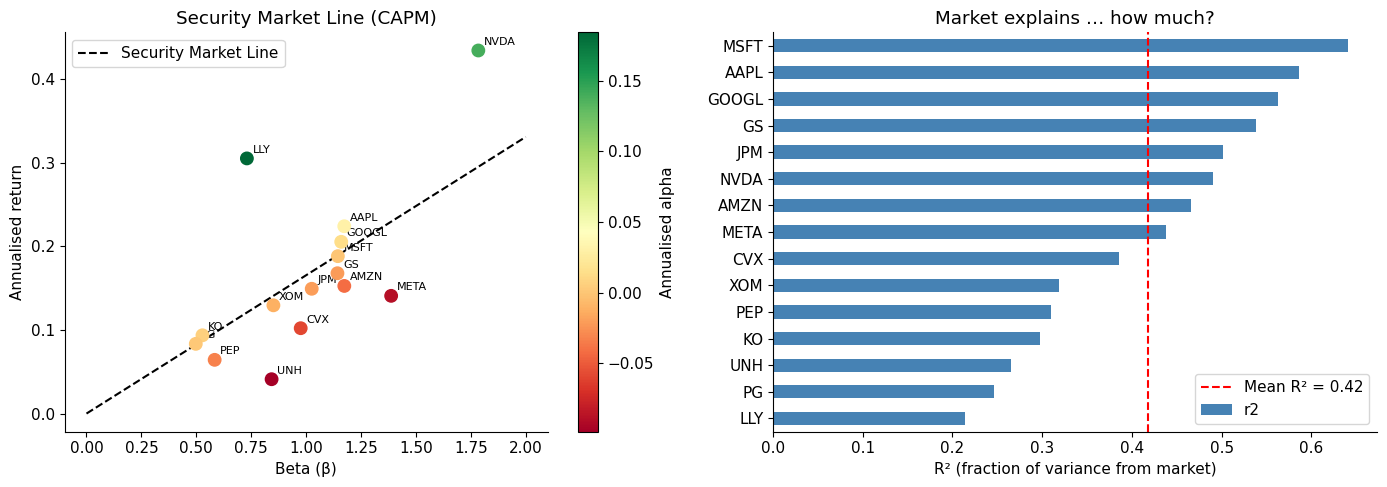


Equity risk premium (annualised): 16.5%
Average R²: 0.42 — the market alone explains ~42% of variance


In [6]:
# ── Plot 1: Security Market Line ─────────────────────────────────────────────
# CAPM predicts that expected return is a linear function of beta.
# Stocks above the SML have positive alpha; below = negative alpha.

ann_ret = log_returns.mean() * 252   # annualised average return
betas = capm['beta']
erp = excess_market.mean() * 252     # empirical equity risk premium

beta_grid = np.linspace(0, 2, 100)
sml = rf + beta_grid * erp           # predicted return under CAPM

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Security Market Line
ax = axes[0]
ax.plot(beta_grid, sml, 'k--', label='Security Market Line')
sc = ax.scatter(betas, ann_ret, c=capm['alpha_ann'], cmap='RdYlGn', s=80, zorder=5)
for t in log_returns.columns:
    ax.annotate(t, (betas[t], ann_ret[t]), fontsize=8,
                xytext=(4, 4), textcoords='offset points')
plt.colorbar(sc, ax=ax, label='Annualised alpha')
ax.set_xlabel('Beta (β)')
ax.set_ylabel('Annualised return')
ax.set_title('Security Market Line (CAPM)')
ax.legend()

# Right: R² histogram — how much is the market explaining?
ax2 = axes[1]
capm['r2'].sort_values().plot(kind='barh', ax=ax2, color='steelblue')
ax2.axvline(capm['r2'].mean(), color='red', linestyle='--',
            label=f'Mean R² = {capm["r2"].mean():.2f}')
ax2.set_xlabel('R² (fraction of variance from market)')
ax2.set_title('Market explains … how much?')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nEquity risk premium (annualised): {erp:.1%}")
print(f"Average R²: {capm['r2'].mean():.2f} — the market alone explains ~{capm['r2'].mean():.0%} of variance")

### What we just learned

- **Beta is not 1 for all stocks.** Growth / tech stocks (NVDA, META) tend to have high beta — they amplify market moves. Defensives (KO, PG, XOM) have lower beta.
- **The market explains 40–70% of a large-cap's daily variance.** The rest is idiosyncratic. That leftover is what stock-pickers try to exploit.
- **Some stocks have meaningful alpha.** But be careful — CAPM alpha can absorb other systematic risks (size, value, momentum) that aren't in the model. This is the whole motivation for multi-factor models.

### Why CAPM breaks in practice

1. **The model is static** — betas change over time (a value stock can become a growth stock)
2. **The market proxy is wrong** — we don't observe the "true" market portfolio (Roll's critique, 1977)
3. **Empirical anomalies** — value, small cap, momentum, profitability all predict returns *after* controlling for beta

These anomalies motivated the multi-factor models in Part 2.

---
## Part 2 — Linear Factor Models

### The general framework

A **linear factor model** decomposes stock returns into:
- Exposure to $K$ common **factors** $\mathbf{f}_t \in \mathbb{R}^K$
- Stock-specific (idiosyncratic) residual $\varepsilon_{i,t}$

$$r_{i,t} = \alpha_i + \sum_{k=1}^K \beta_{ik} f_{k,t} + \varepsilon_{i,t}$$

Or in matrix form for the full cross-section at time $t$:
$$\mathbf{r}_t = \boldsymbol{\alpha} + \mathbf{B}\,\mathbf{f}_t + \boldsymbol{\varepsilon}_t$$

where $\mathbf{B} \in \mathbb{R}^{N\times K}$ is the **factor loading matrix** (also called **beta matrix** or **exposure matrix**).

Key assumptions:
1. $\mathbb{E}[\varepsilon_{i,t}] = 0$ — residuals are zero-mean
2. $\mathrm{Cov}(\varepsilon_{i,t}, f_{k,t}) = 0$ — residuals uncorrelated with factors
3. $\mathrm{Cov}(\varepsilon_{i,t}, \varepsilon_{j,t}) = 0$ for $i\neq j$ — **key simplification**: idiosyncratic risks are independent

Assumption 3 is critical — it's what makes the covariance matrix tractable.

### Types of factors

| Type | Examples | How obtained |
|------|----------|-------------|
| **Macro** | Market, rates, credit spread | Observable time series |
| **Fundamental** | Size (SMB), Value (HML) | Long/short portfolio returns |
| **Statistical** | PC1, PC2, ... | PCA on returns |
| **Characteristic** | Momentum score | Cross-sectional rank |

### Fama-French 3-Factor Model

Fama and French (1993) added two factors to CAPM to capture the empirical anomalies:

$$r_{i,t} - r_f = \alpha_i + \beta_i^{\text{Mkt}}(r_m - r_f) + \beta_i^{\text{SMB}} \cdot \text{SMB}_t + \beta_i^{\text{HML}} \cdot \text{HML}_t + \varepsilon_{i,t}$$

- **MKT**: market excess return (same as CAPM)
- **SMB** (Small Minus Big): return on small stocks minus large stocks — captures size premium
- **HML** (High Minus Low): return on high book-to-market stocks minus low — captures value premium

These factors are **tradable** long-short portfolios, which makes them clean: you can replicate the factor returns by trading.

In [10]:
# ── Construct synthetic SMB and HML proxies from our universe ────────────────
# 
# We don't have market-cap or book-to-market data, so we build proxies:
#   SMB proxy: (small-cap proxies) - (large-cap proxies)
#     We treat NVDA, META, AMZN, MSFT, AAPL, GOOGL as "large"
#     and CVX, KO, GS, JPM, LLY, PEP, PG, UNH, XOM as "other"
#     (rough heuristic — in reality you'd use actual market caps)
#   HML proxy: we use 1-year trailing return as a very rough value proxy
#     (low past return ≈ potentially cheap; high past return ≈ expensive)
#     This is not a real HML but illustrates the construction method.
#
# For real factor data: https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html

large_caps = ['NVDA', 'META', 'AMZN', 'MSFT', 'AAPL', 'GOOGL', 'LLY', 'UNH']
small_caps = [c for c in log_returns.columns if c not in large_caps]

smb_proxy = log_returns[small_caps].mean(axis=1) - log_returns[large_caps].mean(axis=1)
smb_proxy.name = 'SMB_proxy'

# Rolling 252-day return as a crude "cheapness" signal
trailing_ret = log_returns.rolling(252).sum()
# Each day: rank stocks, long bottom 5 (value), short top 5 (growth)
hml_proxy_series = []
for dt in log_returns.index[252:]:
    ranked = trailing_ret.loc[dt].rank()
    value_stocks = ranked[ranked <= 5].index
    growth_stocks = ranked[ranked > ranked.max() - 5].index
    hml_daily = log_returns.loc[dt, value_stocks].mean() - log_returns.loc[dt, growth_stocks].mean()
    hml_proxy_series.append(hml_daily)

hml_proxy = pd.Series(hml_proxy_series, index=log_returns.index[252:], name='HML_proxy')

# Align all factors
factors = pd.concat([
    excess_market.rename('MKT'),
    smb_proxy.rename('SMB'),
    hml_proxy.rename('HML'),
], axis=1).dropna()

print(f"Factor data: {factors.index[0].date()} → {factors.index[-1].date()}")
print(f"\nAnnualised factor returns:")
print((factors.mean() * 252).round(4))
print(f"\nFactor correlation matrix:")
print(factors.corr().round(3))

Factor data: 2019-01-04 → 2026-03-31

Annualised factor returns:
MKT    0.1971
SMB   -0.1017
HML   -0.5646
dtype: float64

Factor correlation matrix:
       MKT    SMB    HML
MKT  1.000 -0.317  0.082
SMB -0.317  1.000  0.303
HML  0.082  0.303  1.000


In [11]:
# ── Run the 3-factor regression for each stock ───────────────────────────────
# OLS: r_i = alpha + B_MKT * MKT + B_SMB * SMB + B_HML * HML + eps

stocks_aligned = excess_stocks.loc[factors.index]
X3 = np.column_stack([np.ones(len(factors)), factors.values])

ff3_results = {}
for ticker in log_returns.columns:
    y = stocks_aligned[ticker].values
    coef, _, _, _ = np.linalg.lstsq(X3, y, rcond=None)
    alpha, b_mkt, b_smb, b_hml = coef
    
    y_hat = X3 @ coef
    ss_res = np.sum((y - y_hat)**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2 = 1 - ss_res / ss_tot
    
    ff3_results[ticker] = {
        'alpha_ann': alpha * 252,
        'beta_MKT': b_mkt,
        'beta_SMB': b_smb,
        'beta_HML': b_hml,
        'r2': r2,
        'idio_vol': np.std(y - y_hat) * np.sqrt(252),
    }

ff3 = pd.DataFrame(ff3_results).T
print("3-Factor model loadings:")
print(ff3.round(3).to_string())

3-Factor model loadings:
       alpha_ann  beta_MKT  beta_SMB  beta_HML     r2  idio_vol
AAPL       0.009     1.078    -0.278    -0.052  0.633     0.185
AMZN      -0.074     0.880    -0.709     0.052  0.626     0.208
CVX       -0.010     1.264     0.803     0.043  0.667     0.186
GOOGL      0.038     0.969    -0.485     0.068  0.641     0.187
GS         0.016     1.329     0.499    -0.033  0.636     0.191
JPM        0.005     1.247     0.592     0.018  0.676     0.169
KO         0.020     0.677     0.392     0.026  0.485     0.142
LLY        0.045     0.728    -0.081    -0.193  0.239     0.284
META       0.014     1.064    -0.879     0.192  0.606     0.265
MSFT      -0.054     0.985    -0.407    -0.023  0.720     0.151
NVDA       0.056     1.486    -0.864    -0.210  0.651     0.300
PEP       -0.039     0.723     0.331    -0.019  0.431     0.160
PG        -0.015     0.601     0.263    -0.024  0.327     0.165
UNH       -0.035     0.812    -0.032     0.165  0.266     0.289
XOM        0.02

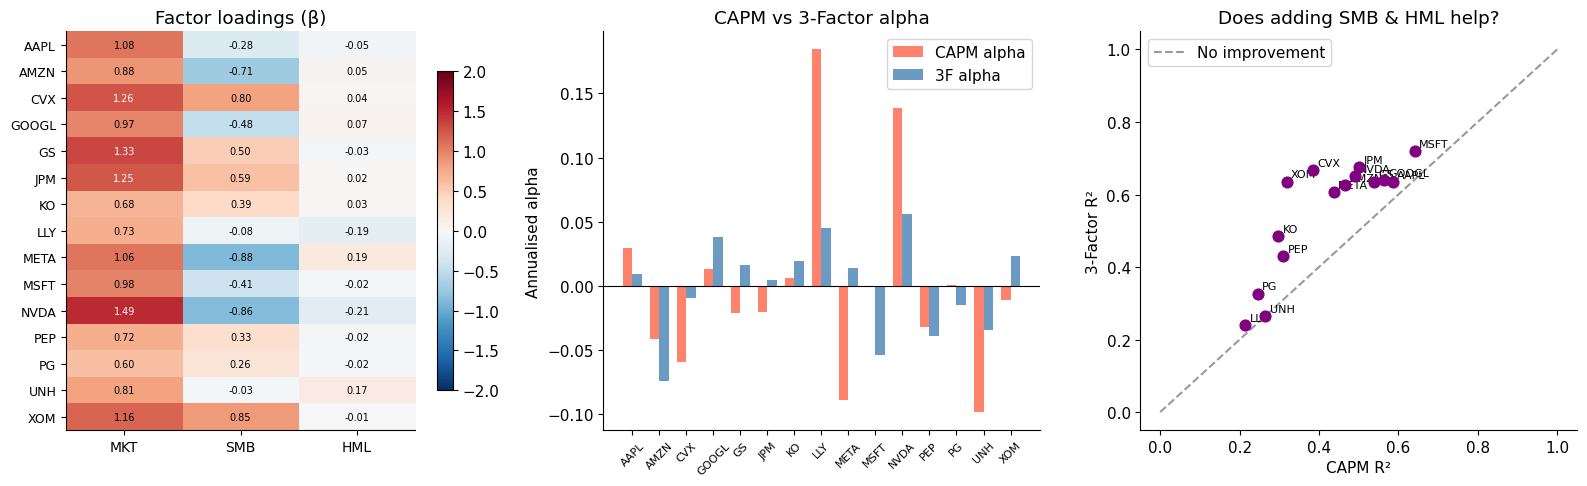

In [12]:
# ── Compare CAPM alpha vs 3-Factor alpha ─────────────────────────────────────
# Adding factors should "explain away" some of the CAPM alpha if those factors
# capture real risk premia.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Factor loadings heatmap
ax = axes[0]
load_cols = ['beta_MKT', 'beta_SMB', 'beta_HML']
loadings = ff3[load_cols]
im = ax.imshow(loadings.values, cmap='RdBu_r', aspect='auto',
               vmin=-2, vmax=2)
ax.set_xticks(range(3))
ax.set_xticklabels(['MKT', 'SMB', 'HML'], fontsize=10)
ax.set_yticks(range(len(ff3)))
ax.set_yticklabels(ff3.index, fontsize=9)
ax.set_title('Factor loadings (β)')
plt.colorbar(im, ax=ax, shrink=0.8)
for i in range(len(ff3)):
    for j, col in enumerate(load_cols):
        ax.text(j, i, f"{loadings.iloc[i,j]:.2f}",
                ha='center', va='center', fontsize=7,
                color='white' if abs(loadings.iloc[i,j]) > 1.2 else 'black')

# Alpha comparison
ax2 = axes[1]
x = np.arange(len(ff3))
width = 0.35
capm_alpha_aligned = capm.loc[ff3.index, 'alpha_ann']
ax2.bar(x - width/2, capm_alpha_aligned, width, label='CAPM alpha', color='tomato', alpha=0.8)
ax2.bar(x + width/2, ff3['alpha_ann'], width, label='3F alpha', color='steelblue', alpha=0.8)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(ff3.index, rotation=45, fontsize=8)
ax2.set_ylabel('Annualised alpha')
ax2.set_title('CAPM vs 3-Factor alpha')
ax2.legend()

# R² improvement
ax3 = axes[2]
capm_r2_aligned = capm.loc[ff3.index, 'r2']
ax3.scatter(capm_r2_aligned, ff3['r2'], s=60, color='purple', zorder=5)
lim = [0, 1]
ax3.plot(lim, lim, 'k--', alpha=0.4, label='No improvement')
for t in ff3.index:
    ax3.annotate(t, (capm_r2_aligned[t], ff3.loc[t,'r2']),
                 fontsize=8, xytext=(3,3), textcoords='offset points')
ax3.set_xlabel('CAPM R²')
ax3.set_ylabel('3-Factor R²')
ax3.set_title('Does adding SMB & HML help?')
ax3.legend()

plt.tight_layout()
plt.show()

### Statistical factors: PCA

Instead of defining factors from theory (market, value, size), we can **extract** them from the data using PCA (Principal Component Analysis).

PCA finds orthogonal directions that maximise explained variance.
In a factor model context, the first PC is (roughly) the market; PC2 and PC3 often correspond to sector or style tilts.

**Why care?**
- No need for pre-specified factor definitions
- PCA factors are orthogonal by construction — no multicollinearity
- Useful for covariance estimation (see Part 3)

**Downside**: PCs are uninterpretable. You can't tell a client "you have a 0.3 loading on PC2."

In [ ]:
# ── PCA on the returns covariance matrix ─────────────────────────────────────
from numpy.linalg import eigh

X = log_returns.values  # T × N
X_dm = X - X.mean(axis=0)  # demean (centre)

# Covariance matrix (N × N)
T, N = X_dm.shape
C = (X_dm.T @ X_dm) / (T - 1)

# Eigendecomposition: C = V Λ Vᵀ  (eigh for symmetric matrices — faster & stable)
eigenvalues, eigenvectors = eigh(C)  # ascending order

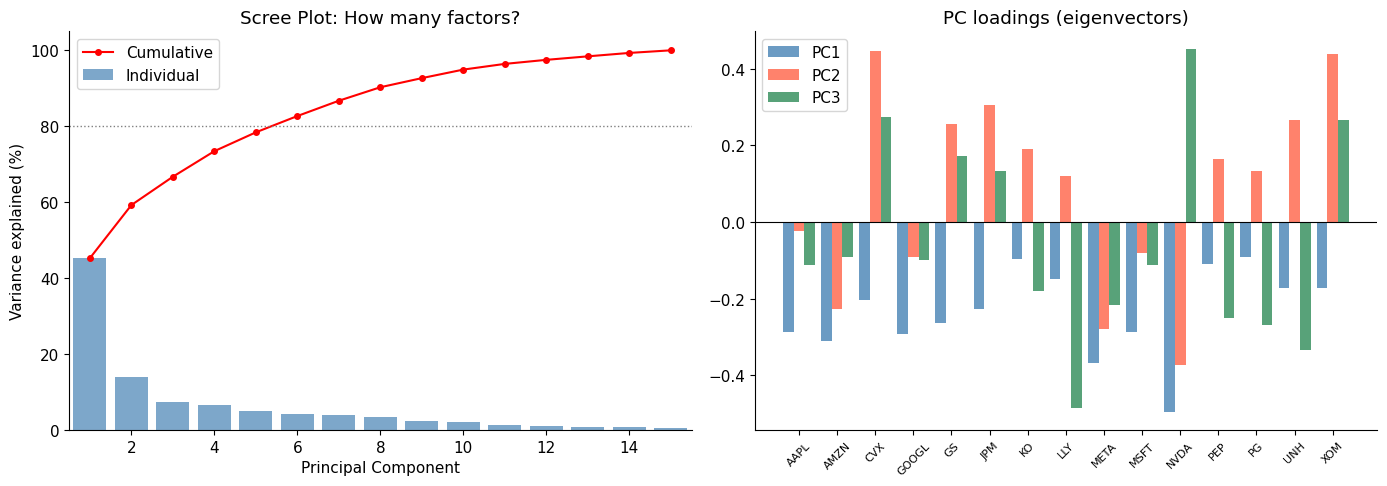


Variance explained by first 5 PCs:
  PC1: 45.3%  (cumulative: 45.3%)
  PC2: 14.0%  (cumulative: 59.3%)
  PC3: 7.5%  (cumulative: 66.7%)
  PC4: 6.7%  (cumulative: 73.5%)
  PC5: 5.0%  (cumulative: 78.4%)


In [14]:
# Flip to descending
eigenvalues = eigenvalues[::-1]
eigenvectors = eigenvectors[:, ::-1]

# Explained variance ratio
explained = eigenvalues / eigenvalues.sum()
cumulative = np.cumsum(explained)

# Factor scores: F = X_dm V  (T × K)
K = 5
pc_scores = pd.DataFrame(
    X_dm @ eigenvectors[:, :K],
    index=log_returns.index,
    columns=[f'PC{k+1}' for k in range(K)]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
ax = axes[0]
bars = ax.bar(range(1, N+1), explained * 100, color='steelblue', alpha=0.7, label='Individual')
ax.plot(range(1, N+1), cumulative * 100, 'r-o', ms=4, label='Cumulative')
ax.axhline(80, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance explained (%)')
ax.set_title('Scree Plot: How many factors?')
ax.legend()
ax.set_xlim([0.5, N + 0.5])

# Loadings of first 3 PCs
ax2 = axes[1]
x = np.arange(N)
width = 0.28
for idx, (label, color) in enumerate([('PC1','steelblue'),('PC2','tomato'),('PC3','seagreen')]):
    ax2.bar(x + (idx-1)*width, eigenvectors[:, idx], width, label=label, alpha=0.8, color=color)
ax2.set_xticks(x)
ax2.set_xticklabels(log_returns.columns, rotation=45, fontsize=8)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('PC loadings (eigenvectors)')
ax2.legend()

plt.tight_layout()
plt.show()

print("\nVariance explained by first 5 PCs:")
for k in range(K):
    print(f"  PC{k+1}: {explained[k]:.1%}  (cumulative: {cumulative[k]:.1%})")

**PC1 loadings are all positive** — this is the market factor. Everything loads on it.
PC2 typically separates energy/defensive from growth/tech.
5 factors explain ~80% of variance in this concentrated universe.

---
## Part 3 — Covariance Matrix Estimation

### Why this is hard

A portfolio of $N$ assets needs the $N \times N$ covariance matrix $\Sigma$.
It has $N(N+1)/2$ unique entries.
With $N=500$ (S&P 500), that's 125,250 parameters to estimate from ~2,500 daily returns.

The **sample covariance matrix** $\hat{\Sigma} = \frac{1}{T-1} X^\top X$ is:
- **Unbiased** when $T > N$
- **Rank-deficient** when $T < N$ (singular, can't be inverted)
- **Very noisy** when $T$ is only moderately larger than $N$

The intuition: with 500 assets and 2 years of daily data ($T \approx 500$), you're estimating 125K parameters from 250K data points. Signal-to-noise is terrible.

### Fix 1 — Ledoit-Wolf Shrinkage

**Shrinkage**: blend the noisy sample covariance toward a structured target $T$:

$$\hat{\Sigma}_{\text{shrink}} = (1-\alpha)\hat{\Sigma} + \alpha \cdot T$$

The Ledoit-Wolf (2004) estimator uses $T = \frac{\mathrm{tr}(\hat{\Sigma})}{N} I$ (scaled identity) and chooses $\alpha$ analytically to minimise expected Frobenius error. No cross-validation needed.

**Intuition**: extreme correlations in $\hat{\Sigma}$ are mostly noise. Shrinking toward the identity pulls correlations toward 0 and equalises variances — a more conservative, regularised estimate.

### Fix 2 — Factor-Based Covariance

Using the factor model $\mathbf{r}_t = \mathbf{B}\mathbf{f}_t + \boldsymbol{\varepsilon}_t$, the covariance structure is:

$$\Sigma = \mathbf{B}\,\Omega_f\,\mathbf{B}^\top + \Delta$$

where:
- $\Omega_f = \mathrm{Cov}(\mathbf{f}_t)$: $K\times K$ factor covariance (small, easy to estimate)
- $\Delta = \mathrm{diag}(\sigma_{\varepsilon_1}^2, \ldots, \sigma_{\varepsilon_N}^2)$: diagonal idiosyncratic covariance

This decomposes the $N\times N$ problem into:
- Estimating $K\times K$ factor covariance ($K \ll N$)
- Estimating $N$ idiosyncratic variances (diagonal only — no cross-stock noise)

This is the **Barra** / **Axioma** / **Northfield** risk model approach — every major buy-side shop uses a variant of this.

In [28]:
# ── Method 1: Sample covariance ───────────────────────────────────────────────
returns_aligned = log_returns.loc[factors.index]  # align with factor data
T_data, N = returns_aligned.shape

X_mat = returns_aligned.values
X_c = X_mat - X_mat.mean(axis=0)

Sigma_sample = (X_c.T @ X_c) / (T_data - 1)

# ── Method 2: Ledoit-Wolf shrinkage ──────────────────────────────────────────
from sklearn.covariance import LedoitWolf
lw = LedoitWolf().fit(X_c)
Sigma_lw = lw.covariance_
print(f"Ledoit-Wolf shrinkage coefficient α = {lw.shrinkage_:.3f}")
print(f"(0 = pure sample covariance, 1 = pure identity target)")

# ── Method 3: Factor-based covariance ─────────────────────────────────────────
# We already estimated B (factor loadings) and residuals in the 3-factor regression.
# Here we use the 5-PC statistical factors for a cleaner construction.

K_factors = 5
B = eigenvectors[:, :K_factors]  # N × K  (loadings from PCA)

# Factor covariance: Ω_f = diag(λ_1, ..., λ_K)  (PCA factors are orthogonal!)
Omega_f = np.diag(eigenvalues[:K_factors] / (T_data - 1))  # scale to daily cov

# Residual returns: eps = X - X * B * Bᵀ
X_reconstructed = (X_c @ B) @ B.T  # T × N
X_residual = X_c - X_reconstructed

# Idiosyncratic variances: diagonal of residual covariance
idio_var = np.var(X_residual, axis=0, ddof=1)  # N-vector
Delta = np.diag(idio_var)

# Factor covariance reconstruction
Sigma_factor = B @ Omega_f @ B.T + Delta

print(f"\nFactor model uses K={K_factors} factors")
print(f"Parameters to estimate: {K_factors*(K_factors+1)//2} (factor cov) + {N} (idio var) = {K_factors*(K_factors+1)//2 + N}")
print(f"Sample cov parameters : {N*(N+1)//2}")
print(f"Reduction factor      : {N*(N+1)//2 / (K_factors*(K_factors+1)//2 + N):.1f}x")

Ledoit-Wolf shrinkage coefficient α = 0.017
(0 = pure sample covariance, 1 = pure identity target)

Factor model uses K=5 factors
Parameters to estimate: 15 (factor cov) + 15 (idio var) = 30
Sample cov parameters : 120
Reduction factor      : 4.0x


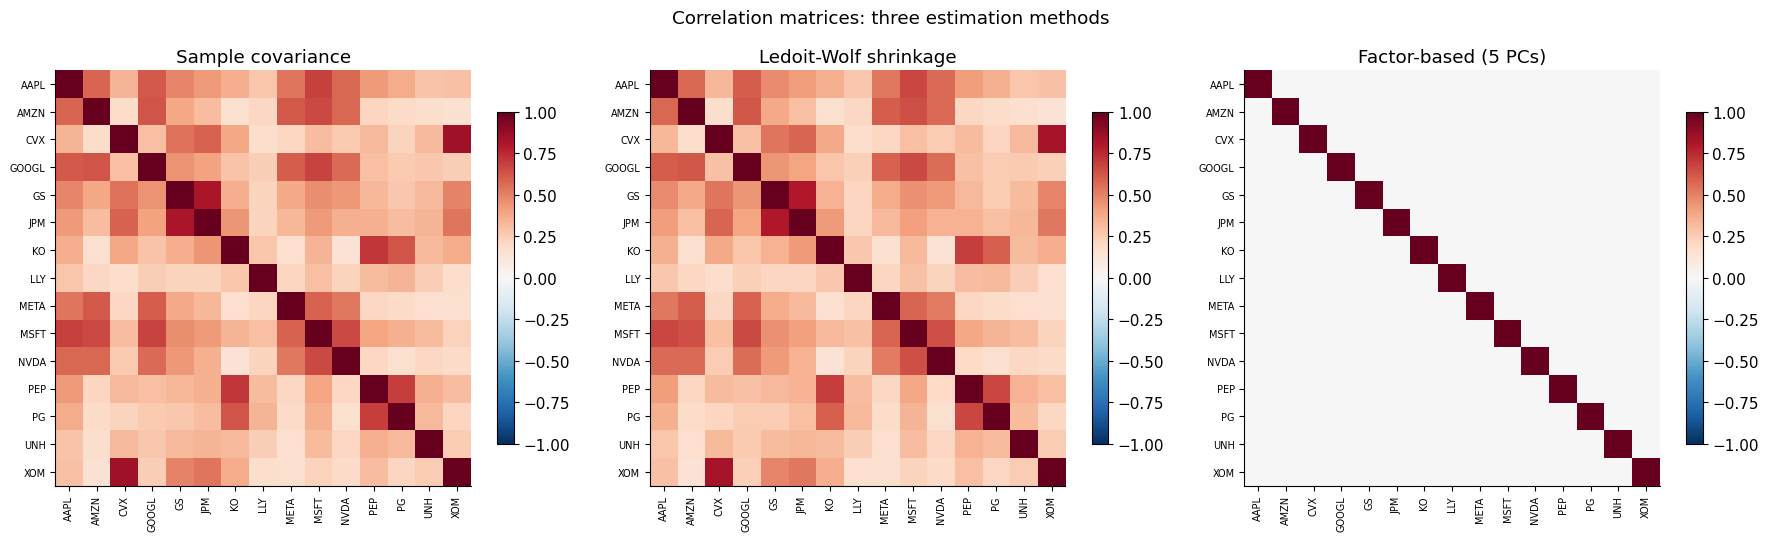

Off-diagonal correlation stats:
  Sample  : mean=0.366, std=0.164, min=0.147, max=0.847
  LW      : mean=0.358, std=0.160, min=0.143, max=0.832
  Factor  : mean=-0.000, std=0.000, min=-0.000, max=0.000


In [30]:
# ── Compare the three covariance matrices visually ────────────────────────────
def to_corr(cov):
    """Convert covariance matrix to correlation matrix."""
    d = np.sqrt(np.diag(cov))
    return cov / np.outer(d, d)

tickers = list(returns_aligned.columns)
corr_sample = to_corr(Sigma_sample)
corr_lw = to_corr(Sigma_lw)
corr_factor = to_corr(Sigma_factor)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, corr, title in zip(
    axes,
    [corr_sample, corr_lw, corr_factor],
    ['Sample covariance', 'Ledoit-Wolf shrinkage', 'Factor-based (5 PCs)'],
):
    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(N))
    ax.set_yticks(range(N))
    ax.set_xticklabels(tickers, rotation=90, fontsize=7)
    ax.set_yticklabels(tickers, fontsize=7)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Correlation matrices: three estimation methods', y=1.02)
plt.tight_layout()
plt.show()

# Key statistics
print("Off-diagonal correlation stats:")
mask = ~np.eye(N, dtype=bool)
for name, corr in [('Sample', corr_sample), ('LW', corr_lw), ('Factor', corr_factor)]:
    vals = corr[mask]
    print(f"  {name:8s}: mean={vals.mean():.3f}, std={vals.std():.3f}, min={vals.min():.3f}, max={vals.max():.3f}")

**What to notice:**
- **Sample cov** can have extreme correlations (some near ±1) that are almost certainly noise
- **Ledoit-Wolf** pulls everything toward zero — more conservative, rounder estimates
- **Factor-based** has a clean structure: the off-diagonal correlations come entirely from shared factor exposures. No correlation between stocks that load differently on all factors

The factor model imposes **more structure** — it will be wrong if stocks have cross-correlations beyond what the factors capture. But that structure is exactly what makes the estimator stable with limited data.

---
## Part 4 — Mean-Variance Optimisation

### The Markowitz framework

Given $N$ assets with expected returns $\boldsymbol{\mu}$ and covariance $\Sigma$, Markowitz (1952) asks:

> *What is the minimum-variance portfolio achieving expected return $\mu^*$?*

$$\min_{\mathbf{w}} \; \mathbf{w}^\top \Sigma \mathbf{w} \quad \text{s.t.} \quad \mathbf{w}^\top \boldsymbol{\mu} = \mu^*, \; \mathbf{1}^\top \mathbf{w} = 1$$

Sweeping $\mu^*$ from low to high traces out the **efficient frontier**.

In practice, quants often maximise **Sharpe ratio** instead:

$$\max_{\mathbf{w}} \; \frac{\mathbf{w}^\top \boldsymbol{\mu} - r_f}{\sqrt{\mathbf{w}^\top \Sigma \mathbf{w}}}$$

This has a **closed-form solution** (when unconstrained):

$$\mathbf{w}^* \propto \Sigma^{-1} \boldsymbol{\mu}$$

### The problem in practice

Mean-variance optimisation is **notoriously sensitive** to estimation error in $\boldsymbol{\mu}$.
The optimizer "concentrates" risk in assets with high estimated expected return — which are often just the ones with the most estimation error.

Rule of thumb: **garbage in, garbage out**. This is why robust covariance estimation (Part 3) matters, and why many practitioners:
1. Use risk parity / equal-weight as a simpler alternative
2. Apply turnover and concentration constraints
3. Shrink alpha estimates heavily
4. Separate alpha estimation from risk estimation

In [31]:
# ── Build the efficient frontier ──────────────────────────────────────────────
# We use historical mean returns as our "alpha" (very noisy but illustrative).
# In a real shop you'd feed factor model alpha estimates here.

mu = returns_aligned.mean().values * 252        # annualised expected returns
Sigma_ann = Sigma_lw * 252                       # annualise covariance
Sigma_factor_ann = Sigma_factor * 252

def portfolio_stats(w, mu, Sigma):
    ret = w @ mu
    vol = np.sqrt(w @ Sigma @ w)
    sharpe = ret / vol
    return ret, vol, sharpe

def max_sharpe(mu, Sigma):
    """Numerically maximise Sharpe (long-only)."""
    N = len(mu)
    def neg_sharpe(w):
        r, v, _ = portfolio_stats(w, mu, Sigma)
        return -r / v if v > 0 else np.inf
    constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
    bounds = [(0, 1)] * N  # long-only
    w0 = np.ones(N) / N
    res = minimize(neg_sharpe, w0, method='SLSQP',
                   bounds=bounds, constraints=constraints,
                   options={'ftol': 1e-12, 'maxiter': 1000})
    return res.x

def efficient_frontier(mu, Sigma, n_points=60):
    """Trace the efficient frontier."""
    N = len(mu)
    mu_min = mu.min() * 0.5
    mu_max = mu.max() * 1.1
    targets = np.linspace(mu_min, mu_max, n_points)
    frontier = []
    for target in targets:
        constraints = [
            {'type': 'eq', 'fun': lambda w: w.sum() - 1},
            {'type': 'eq', 'fun': lambda w, t=target: w @ mu - t},
        ]
        bounds = [(0, 1)] * N
        res = minimize(lambda w: w @ Sigma @ w, np.ones(N)/N,
                       method='SLSQP', bounds=bounds, constraints=constraints)
        if res.success:
            _, vol, _ = portfolio_stats(res.x, mu, Sigma)
            frontier.append((vol, target))
    return np.array(frontier)

# Individual stock stats
stock_vol = np.sqrt(np.diag(Sigma_ann))

# Max Sharpe portfolios
w_ms_sample = max_sharpe(mu, Sigma_ann)
w_ms_lw = max_sharpe(mu, Sigma_lw * 252)
w_ms_factor = max_sharpe(mu, Sigma_factor_ann)

# Equal-weight benchmark
w_ew = np.ones(N) / N

print("Portfolio stats (annualised):")
print(f"{'':20s} {'Return':>8s} {'Vol':>8s} {'Sharpe':>8s}")
print('-' * 48)
for label, w, Sig in [
    ('Equal-weight', w_ew, Sigma_ann),
    ('Max Sharpe (sample)', w_ms_sample, Sigma_ann),
    ('Max Sharpe (LW)', w_ms_lw, Sigma_lw*252),
    ('Max Sharpe (factor)', w_ms_factor, Sigma_factor_ann),
]:
    r, v, s = portfolio_stats(w, mu, Sig)
    print(f"{label:20s} {r:8.2%} {v:8.2%} {s:8.2f}")

Portfolio stats (annualised):
                       Return      Vol   Sharpe
------------------------------------------------
Equal-weight           19.71%   19.95%     0.99
Max Sharpe (sample)    34.85%   25.83%     1.35
Max Sharpe (LW)        34.85%   25.83%     1.35
Max Sharpe (factor)    20.91%    7.98%     2.62


Computing frontiers... (may take ~10s)


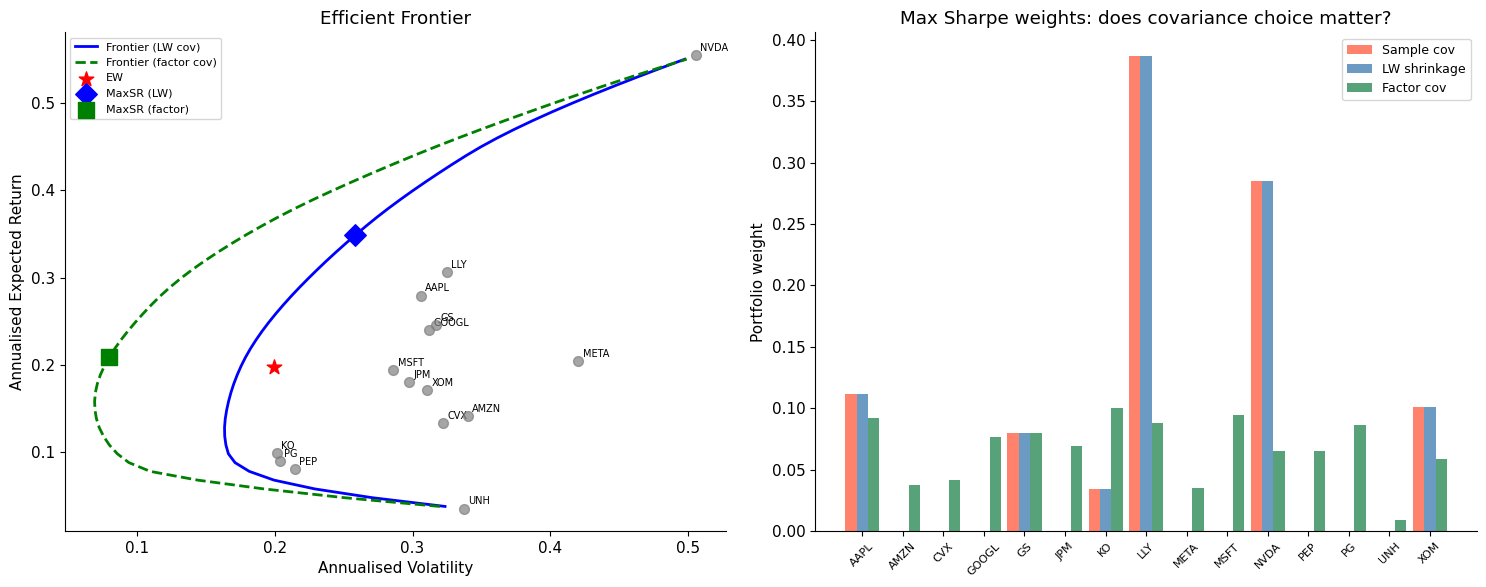

In [32]:
# ── Plot: Efficient Frontier ───────────────────────────────────────────────────
print("Computing frontiers... (may take ~10s)")
frontier_lw = efficient_frontier(mu, Sigma_lw * 252)
frontier_factor = efficient_frontier(mu, Sigma_factor_ann)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Efficient frontier
ax = axes[0]
if len(frontier_lw) > 0:
    ax.plot(frontier_lw[:, 0], frontier_lw[:, 1], 'b-', label='Frontier (LW cov)', lw=2)
if len(frontier_factor) > 0:
    ax.plot(frontier_factor[:, 0], frontier_factor[:, 1], 'g--', label='Frontier (factor cov)', lw=2)

# Individual stocks
ax.scatter(stock_vol, mu, s=50, c='gray', zorder=5, alpha=0.7)
for i, t in enumerate(tickers):
    ax.annotate(t, (stock_vol[i], mu[i]), fontsize=7,
                xytext=(3, 3), textcoords='offset points')

# Optimal portfolios
for label, w, Sig, color, marker in [
    ('EW', w_ew, Sigma_ann, 'red', '*'),
    ('MaxSR (LW)', w_ms_lw, Sigma_lw*252, 'blue', 'D'),
    ('MaxSR (factor)', w_ms_factor, Sigma_factor_ann, 'green', 's'),
]:
    r, v, _ = portfolio_stats(w, mu, Sig)
    ax.scatter(v, r, s=120, c=color, marker=marker, zorder=10, label=label)

ax.set_xlabel('Annualised Volatility')
ax.set_ylabel('Annualised Expected Return')
ax.set_title('Efficient Frontier')
ax.legend(fontsize=8)

# Right: Max Sharpe weight comparison — how does covariance choice affect allocations?
ax2 = axes[1]
x = np.arange(N)
width = 0.28
ax2.bar(x - width, w_ms_sample, width, label='Sample cov', color='tomato', alpha=0.8)
ax2.bar(x, w_ms_lw, width, label='LW shrinkage', color='steelblue', alpha=0.8)
ax2.bar(x + width, w_ms_factor, width, label='Factor cov', color='seagreen', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(tickers, rotation=45, fontsize=8)
ax2.set_ylabel('Portfolio weight')
ax2.set_title('Max Sharpe weights: does covariance choice matter?')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

### The key takeaway

The efficient frontier and optimal portfolio weights **depend heavily on which covariance estimator you use**. This is a key practical insight:

- The **sample covariance** max-Sharpe portfolio often concentrates aggressively in a few stocks (it exploits noise)
- **Ledoit-Wolf** produces more diversified weights by shrinking extreme pairwise correlations
- The **factor covariance** model gives the most structured result — it essentially optimises within the factor model's view of risk

In production: most quant shops add **constraints** (max weight per stock, sector limits, turnover limits, net/gross exposure limits) on top of the optimiser to prevent degenerate solutions.

---
## Part 5 — Rolling Estimation & Time-Varying Betas

All the models above assume **stationarity** — the relationships don't change over time. That's clearly wrong.
Tech stocks had very different betas in 2020 (COVID crash/recovery) vs 2022 (rate hike drawdown).

Two practical approaches:
1. **Rolling window** — re-estimate over the past $W$ days at each point in time
2. **Exponentially weighted** — down-weight old data, up-weight recent data using decay factor $\lambda \in (0,1)$

$$\hat{\Sigma}_t = (1-\lambda) \sum_{s=0}^{t} \lambda^{t-s} (r_s - \bar{r})(r_s - \bar{r})^\top$$

Half-life $h$: $\lambda = 0.5^{1/h}$ — observations older than $h$ days contribute less than 50% weight.

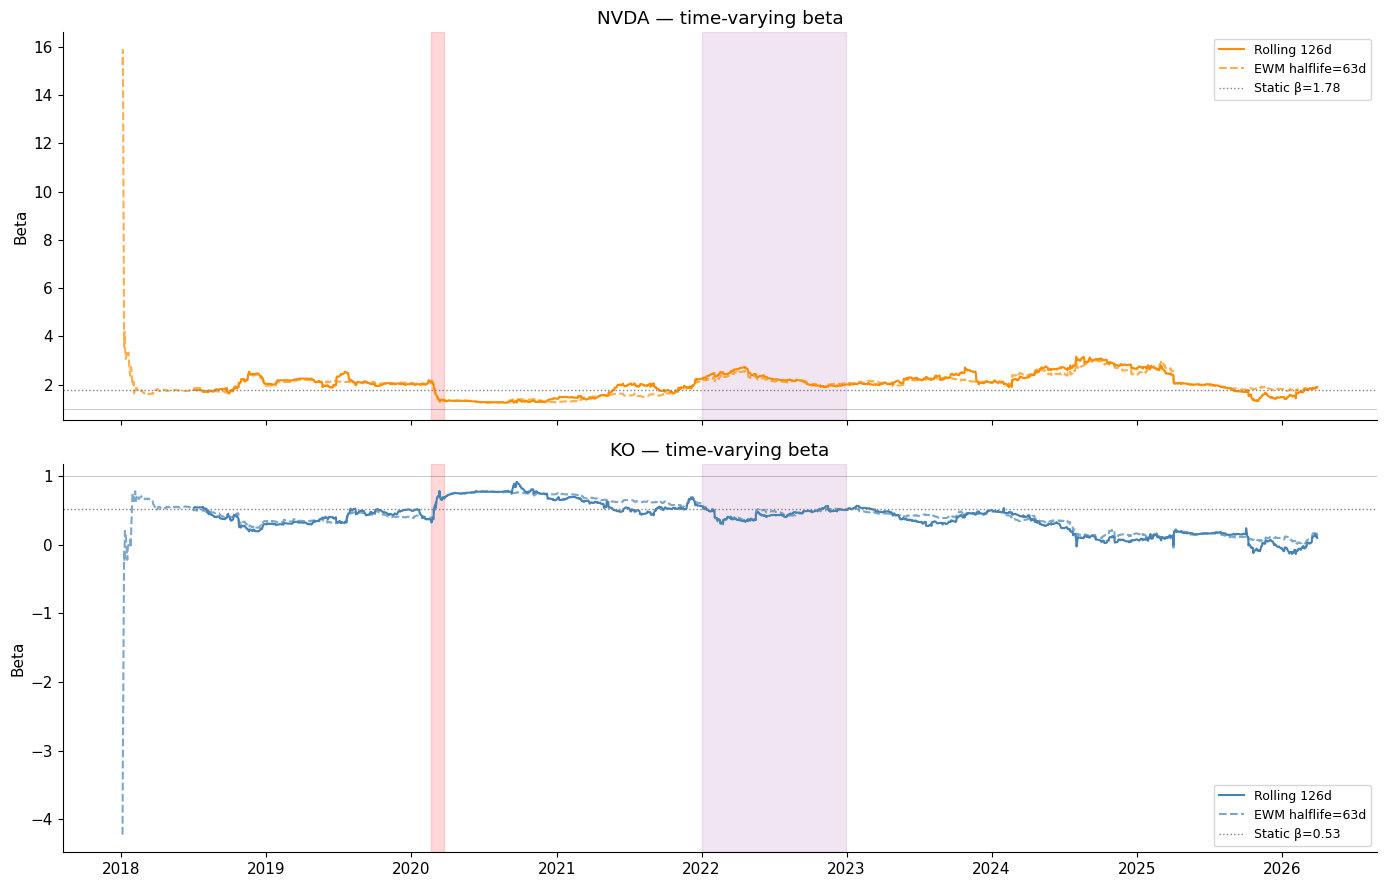

In [33]:
# ── Rolling beta for NVDA and KO (high vs low beta) ───────────────────────────
WINDOW = 126   # ~6 months
HALFLIFE = 63  # ~3 months

def rolling_beta(stock_ret, market_ret, window):
    """Compute rolling OLS beta."""
    # Efficient: use pandas rolling cov/var
    cov_im = stock_ret.rolling(window).cov(market_ret)
    var_m = market_ret.rolling(window).var()
    return cov_im / var_m

def ewm_beta(stock_ret, market_ret, halflife):
    """Exponentially weighted beta."""
    cov_im = stock_ret.ewm(halflife=halflife).cov(market_ret)
    var_m = market_ret.ewm(halflife=halflife).var()
    return cov_im / var_m

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for ax, ticker, color in zip(axes, ['NVDA', 'KO'], ['darkorange', 'steelblue']):
    s = log_returns[ticker]
    
    beta_roll = rolling_beta(s, market_ret, WINDOW)
    beta_ewm = ewm_beta(s, market_ret, HALFLIFE)
    static_beta = capm.loc[ticker, 'beta']
    
    ax.plot(beta_roll, label=f'Rolling {WINDOW}d', color=color, lw=1.5)
    ax.plot(beta_ewm, label=f'EWM halflife={HALFLIFE}d', color=color, lw=1.5, linestyle='--', alpha=0.7)
    ax.axhline(static_beta, color='gray', lw=1, linestyle=':', label=f'Static β={static_beta:.2f}')
    ax.axhline(1.0, color='black', lw=0.5, alpha=0.3)
    ax.set_ylabel('Beta')
    ax.set_title(f'{ticker} — time-varying beta')
    ax.legend(fontsize=9)

    # Shade COVID crash
    ax.axvspan(pd.Timestamp('2020-02-19'), pd.Timestamp('2020-03-23'),
               alpha=0.15, color='red', label='COVID crash')
    ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'),
               alpha=0.10, color='purple', label='2022 rate hikes')

plt.tight_layout()
plt.show()

---
## Part 6 — Putting It All Together: A Simple Factor Portfolio

This is how buy-side quants actually build portfolios:

1. **Signal generation**: compute a score $s_i$ for each stock (e.g., 12-1 momentum)
2. **Cross-sectional normalisation**: rank and z-score across the universe at each $t$
3. **Alpha vector**: $\boldsymbol{\alpha} = $ normalised scores (your predicted excess returns)
4. **Risk model**: $\Sigma = \mathbf{B}\Omega_f\mathbf{B}^\top + \Delta$ from the factor model
5. **Optimisation**: $\max_\mathbf{w} \; \boldsymbol{\alpha}^\top \mathbf{w} - \frac{\lambda}{2} \mathbf{w}^\top \Sigma \mathbf{w}$

The risk-aversion parameter $\lambda$ controls the return-risk trade-off. It's typically chosen to hit a target ex-ante vol or Sharpe.

The optimiser balances:
- **Maximise alpha**: buy high-signal stocks, sell low-signal stocks
- **Minimise factor risk**: avoid large bets on MKT, value, size that aren't in your alpha
- **Minimise idiosyncratic risk**: diversify across stocks

Here we use momentum (12-1 month return) as the signal.

In [34]:
# ── Momentum signal ───────────────────────────────────────────────────────────
# 12-1 month momentum: cumulative return from t-252 to t-21
# (skip the last month to avoid short-term reversal)

mom_raw = log_returns.rolling(252).sum() - log_returns.rolling(21).sum()

# Cross-sectional z-score (rank-based is more robust)
def cs_zscore(df):
    """Cross-sectional z-score: demean and scale each row."""
    mu = df.mean(axis=1)
    sigma = df.std(axis=1)
    return df.sub(mu, axis=0).div(sigma, axis=0)

mom_signal = cs_zscore(mom_raw).dropna()

# ── Walk-forward portfolio construction ───────────────────────────────────────
# Monthly rebalancing: at each month-end, compute weights and hold for 1 month

rebal_dates = pd.date_range(
    start=mom_signal.index[0],
    end=mom_signal.index[-1],
    freq='ME'   # month-end
)
rebal_dates = rebal_dates[rebal_dates.isin(mom_signal.index)]

LAMBDA_RISK = 10.0   # risk aversion (higher = less risk, smaller positions)

def build_factor_portfolio(alpha_vec, Sigma, lambda_risk, long_short=True):
    """
    Solve: max alpha'w - (lambda/2) w'Σw
    Closed-form: w* = (1/lambda) * Σ^{-1} * alpha
    Then normalise to dollar-neutral (long-short) or unit gross (long-only).
    """
    Sigma_inv = np.linalg.solve(Sigma, np.eye(len(alpha_vec)))
    w = (1.0 / lambda_risk) * (Sigma_inv @ alpha_vec)
    if long_short:
        # Dollar-neutral: rescale so |w+| = |w-| = 0.5
        w_pos = w.copy(); w_pos[w < 0] = 0
        w_neg = w.copy(); w_neg[w > 0] = 0
        if w_pos.sum() > 0:
            w_pos /= (2 * w_pos.sum())
        if w_neg.sum() < 0:
            w_neg /= (2 * abs(w_neg.sum()))
        w = w_pos + w_neg
    return w

portfolio_weights = []
ESTIMATION_WINDOW = 252  # 1 year of daily data for cov estimation

for dt in rebal_dates[1:]:  # skip first (need history)
    loc = log_returns.index.get_loc(dt)
    if loc < ESTIMATION_WINDOW:
        continue
    
    # Estimate covariance from recent window
    hist = log_returns.iloc[loc - ESTIMATION_WINDOW:loc].values
    lw_est = LedoitWolf().fit(hist)
    Sigma_t = lw_est.covariance_ * 252
    
    # Alpha vector from signal
    alpha_t = mom_signal.loc[dt].values
    
    w = build_factor_portfolio(alpha_t, Sigma_t, LAMBDA_RISK, long_short=True)
    portfolio_weights.append(pd.Series(w, index=log_returns.columns, name=dt))

weights_df = pd.DataFrame(portfolio_weights)
print(f"Portfolio weights computed for {len(weights_df)} rebalance dates")
print(f"\nSample weights (latest):")
print(weights_df.iloc[-1].round(3).sort_values(ascending=False))

Portfolio weights computed for 59 rebalance dates

Sample weights (latest):
Ticker
GOOGL    0.206
GS       0.120
XOM      0.090
NVDA     0.069
KO       0.011
PEP      0.003
LLY     -0.005
META    -0.034
JPM     -0.041
AAPL    -0.054
CVX     -0.054
UNH     -0.069
AMZN    -0.070
MSFT    -0.086
PG      -0.087
Name: 2026-03-31 00:00:00, dtype: float64


In [35]:
# ── Backtest: compute portfolio returns ───────────────────────────────────────
# For each period [t, t+1], apply weights set at t to returns at t+1
# Using simple returns for portfolio arithmetic

simple_returns = pd.read_parquet('../data/processed/returns.parquet')

port_returns = []
for i in range(len(weights_df) - 1):
    t_start = weights_df.index[i]
    t_end = weights_df.index[i + 1]
    
    # Returns over the holding period
    mask = (simple_returns.index > t_start) & (simple_returns.index <= t_end)
    period_ret = simple_returns.loc[mask]
    
    if len(period_ret) == 0:
        continue
    
    w = weights_df.iloc[i].values
    daily_port = period_ret.values @ w
    for dt, r in zip(period_ret.index, daily_port):
        port_returns.append({'date': dt, 'strategy': r,
                             'market': simple_returns.loc[dt].mean()})

bt = pd.DataFrame(port_returns).set_index('date')

# Cumulative wealth
cum = (1 + bt).cumprod()

# Performance stats
def perf_stats(r, ann=252):
    r = r.dropna()
    mean_r = r.mean() * ann
    vol_r = r.std() * np.sqrt(ann)
    sharpe = mean_r / vol_r
    max_dd = ((1+r).cumprod() / (1+r).cumprod().cummax() - 1).min()
    return {'Ann. Return': mean_r, 'Ann. Vol': vol_r,
            'Sharpe': sharpe, 'Max DD': max_dd}

print("Performance summary:")
stats = pd.DataFrame({k: perf_stats(bt[k]) for k in ['strategy', 'market']})
print(stats.round(3))

Performance summary:
             strategy  market
Ann. Return     0.026   0.238
Ann. Vol        0.087   0.201
Sharpe          0.293   1.180
Max DD         -0.145  -0.327


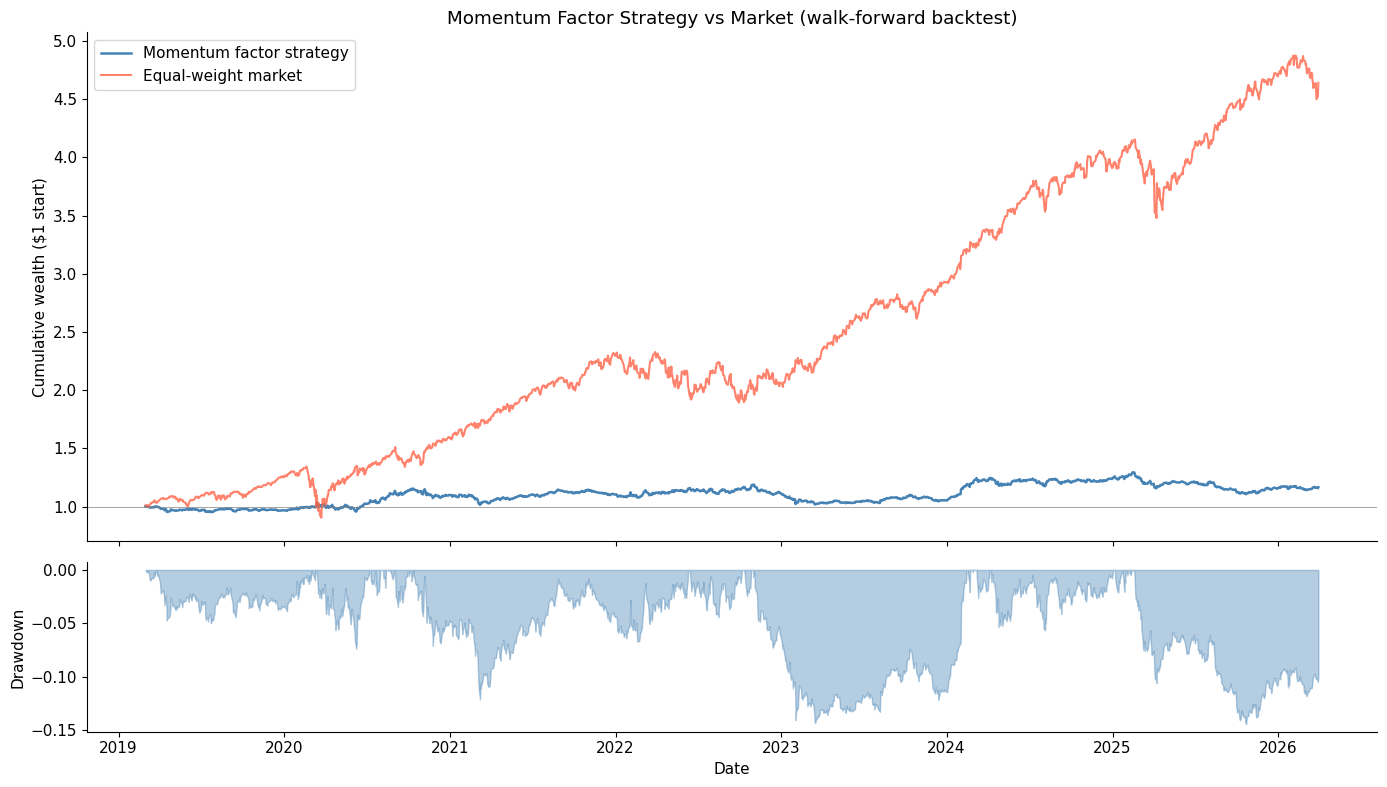


Final performance (annualised):

Momentum strategy:
  Ann. Return    : +2.56%
  Ann. Vol       : +8.75%
  Sharpe         : 0.29
  Max DD         : -14.46%

Equal-weight market:
  Ann. Return    : +23.76%
  Ann. Vol       : +20.13%
  Sharpe         : 1.18
  Max DD         : -32.69%


In [36]:
# ── Final plot: strategy vs market ────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})

ax = axes[0]
ax.plot(cum['strategy'], label='Momentum factor strategy', color='steelblue', lw=1.8)
ax.plot(cum['market'], label='Equal-weight market', color='tomato', lw=1.5, alpha=0.8)
ax.set_ylabel('Cumulative wealth ($1 start)')
ax.set_title('Momentum Factor Strategy vs Market (walk-forward backtest)')
ax.legend()
ax.axhline(1, color='gray', lw=0.5)

# Drawdown
ax2 = axes[1]
cum_strat = cum['strategy']
drawdown = cum_strat / cum_strat.cummax() - 1
ax2.fill_between(drawdown.index, drawdown, 0, color='steelblue', alpha=0.4)
ax2.set_ylabel('Drawdown')
ax2.set_xlabel('Date')

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("Final performance (annualised):")
print("="*50)
for col, label in [('strategy', 'Momentum strategy'), ('market', 'Equal-weight market')]:
    s = perf_stats(bt[col])
    print(f"\n{label}:")
    for k, v in s.items():
        print(f"  {k:15s}: {v:+.2%}" if 'Return' in k or 'DD' in k or 'Vol' in k
              else f"  {k:15s}: {v:.2f}")

---
## Summary: What We Covered

| Model | Key idea | Main use |
|-------|----------|----------|
| **CAPM** | One factor (market) explains risk premia | Benchmark, cost of capital, beta estimation |
| **Fama-French** | Market + Size + Value factors | Alpha attribution, performance attribution |
| **PCA / statistical factors** | Extract factors from return variance | Covariance estimation, risk decomposition |
| **Sample covariance** | Raw second-moment estimator | Baseline, breaks at $T \approx N$ |
| **Ledoit-Wolf** | Shrink toward identity | Robust large-N covariance |
| **Factor covariance** | $B\Omega B^\top + \Delta$ from factor model | Production risk models (Barra, Axioma) |
| **Markowitz / Max SR** | $\Sigma^{-1}\mu$ is the tangency portfolio | Portfolio construction |
| **Factor portfolio** | Combine alpha vector with risk model | The actual quant PM workflow |

### The quant workflow (distilled)

```
Signal research   →  alpha vector α (what you think will outperform)
Risk estimation   →  Σ = B Ω Bᵀ + Δ  (factor risk model)
Optimisation      →  w* = argmax αᵀw - (λ/2) wᵀΣw  s.t. constraints
Execution         →  trade to w* with transaction cost model
Performance eval  →  IC, ICIR, attribution (did alpha deliver?)
```

### What to explore next
- **IC (Information Coefficient)**: correlation of predicted vs realised returns — the quant signal metric
- **Fama-MacBeth regression**: cross-sectional regression to test if a factor is priced
- **Transaction cost modelling**: square-root market impact, bid-ask, optimal rebalancing frequency
- **Barra-style commercial risk models**: more factors, more sophisticated covariance estimation
- **Machine learning alphas**: how to feed ML predictions into the above framework correctly

---
Showing how factors help us to estimate covariance matrices
---

In [39]:
# ── Method 1: Sample covariance ───────────────────────────────────────────────
returns_aligned = log_returns.loc[factors.index]  # align with factor data
T_data, N = returns_aligned.shape

X_mat = returns_aligned.values
X_c = X_mat - X_mat.mean(axis=0)

Sigma_sample = (X_c.T @ X_c) / (T_data - 1)

In [42]:
X_mat.shape

(1819, 15)

In [ ]:
X_test = X_mat[0:10]


Sigma_test = (X_test - X_test.mean(axis=0)).T @ (X_test - X_test.mean(axis=0)) / (len(X_test) - 1)
u_test, v_test = np.linalg.eigh(Sigma_test)
u_test = u_test[::-1]
v_test = v_test[:, ::-1]
u_PCA = u_test[:5]
v_PCA = v_test[:, :5]

In [57]:
X_PCA = X_test @ v_PCA